In [75]:
import pandas as pd

# Load the CSV
df = pd.read_csv('/home/sumittapa/PycharmProjects/SIP_Project/sip_data.csv')

# Convert to datetime - more robust approach
df['Date'] = pd.to_datetime(
    df['Month'] + ' ' + df['Year'].astype(str),
    format='%B %Y'
)

# Set index and sort - using copy to avoid chained assignment
df = df.set_index('Date').sort_index()

# Forward fill missing values - modern syntax
df['SIP_Inflow_Crores'] = df['SIP_Inflow_Crores'].ffill()

# Verify
print(df.head())
print("\nMissing values:", df['SIP_Inflow_Crores'].isnull().sum())

             Month  Year  SIP_Inflow_Crores
Date                                       
2016-04-01   April  2016             3122.0
2016-05-01     May  2016             3189.0
2016-06-01    June  2016             3310.0
2016-07-01    July  2016             3334.0
2016-08-01  August  2016             3497.0

Missing values: 0


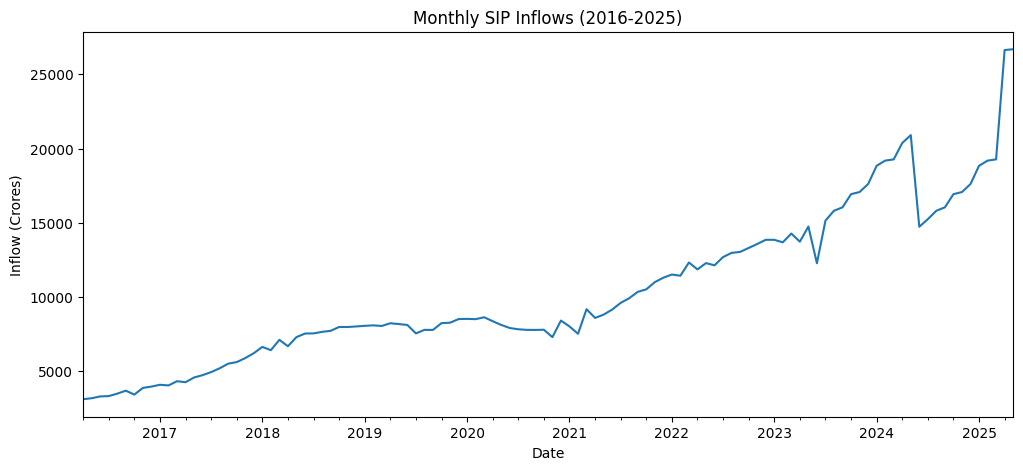

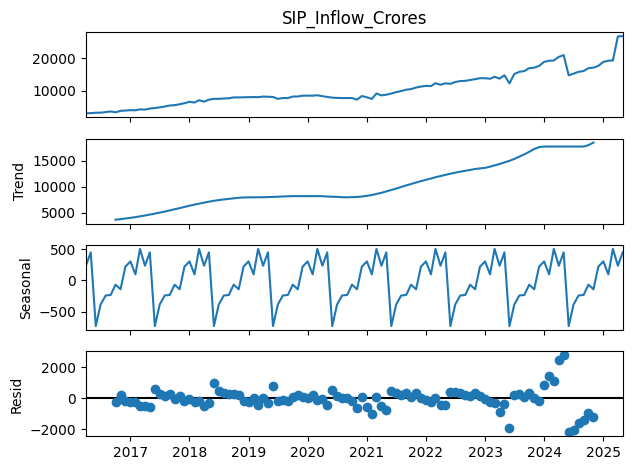

In [76]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Plot raw data
df['SIP_Inflow_Crores'].plot(title='Monthly SIP Inflows (2016-2025)', figsize=(12, 5))
plt.ylabel('Inflow (Crores)')
plt.show()

# Decompose into Trend + Seasonality
result = seasonal_decompose(df['SIP_Inflow_Crores'], model='additive', period=12)
result.plot()
plt.show()

17:24:20 - cmdstanpy - INFO - Chain [1] start processing
17:24:20 - cmdstanpy - INFO - Chain [1] done processing


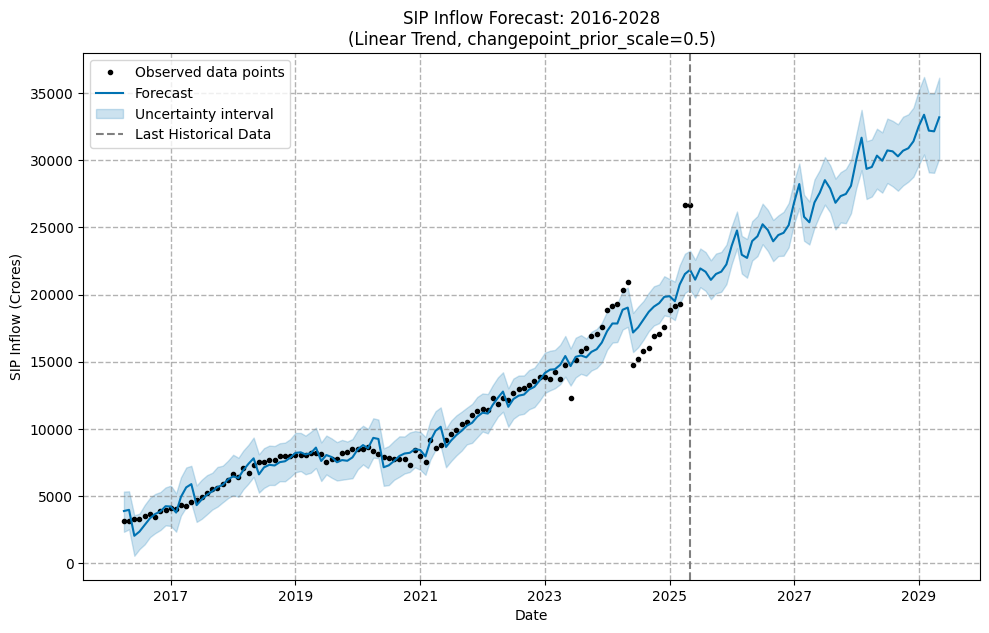

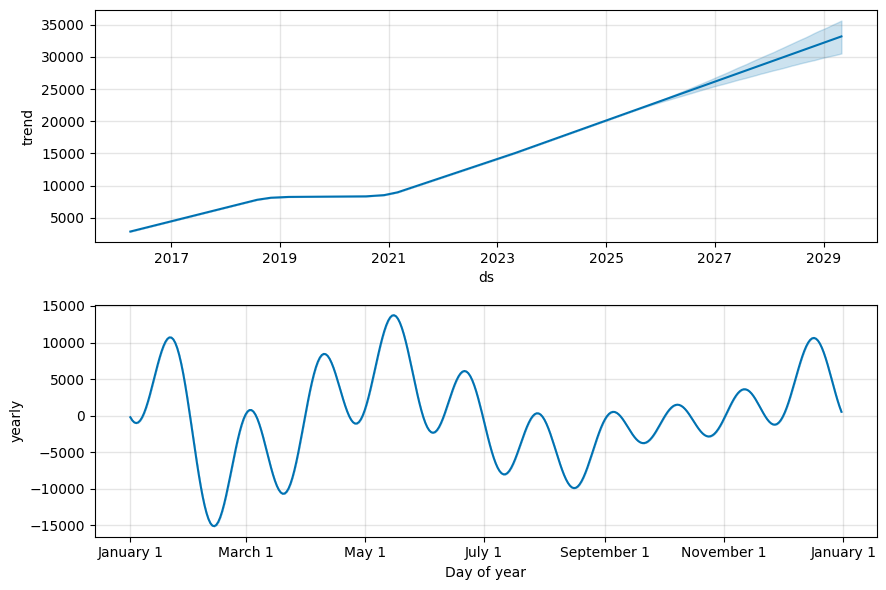

In [77]:
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Prepare data (ensure 'Date' is datetime)
prophet_df = (
    df.reset_index()[['Date', 'SIP_Inflow_Crores']]
    .rename(columns={'Date': 'ds', 'SIP_Inflow_Crores': 'y'})
)
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])  # Ensure datetime format

# 2. Fit model with explicit parameters
model = Prophet(
    growth='linear',
    changepoint_prior_scale=0.5,   # Medium trend flexibility
    yearly_seasonality=True,       # Annual patterns
    weekly_seasonality=False,      # Disabled for monthly data
    daily_seasonality=False,       # Disabled for monthly data
    seasonality_mode='additive'    # Default (alternative: 'multiplicative')
)

model.fit(prophet_df)

# 3. Forecast (use 'ME' instead of deprecated 'M' for Month End)
future = model.make_future_dataframe(periods=48, freq='ME')  # 'ME' = Month End
forecast = model.predict(future)

# 4. Enhanced plotting
fig = model.plot(forecast, xlabel='Date', ylabel='SIP Inflow (Crores)')
plt.title('SIP Inflow Forecast: 2016-2028\n(Linear Trend, changepoint_prior_scale=0.5)')
plt.axvline(
    x=prophet_df['ds'].max(),
    color='grey',
    linestyle='--',
    label='Last Historical Data'
)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)  # Add grid for readability
plt.show()

# Optional: Plot components (trend, yearly seasonality)
fig2 = model.plot_components(forecast)
plt.show()

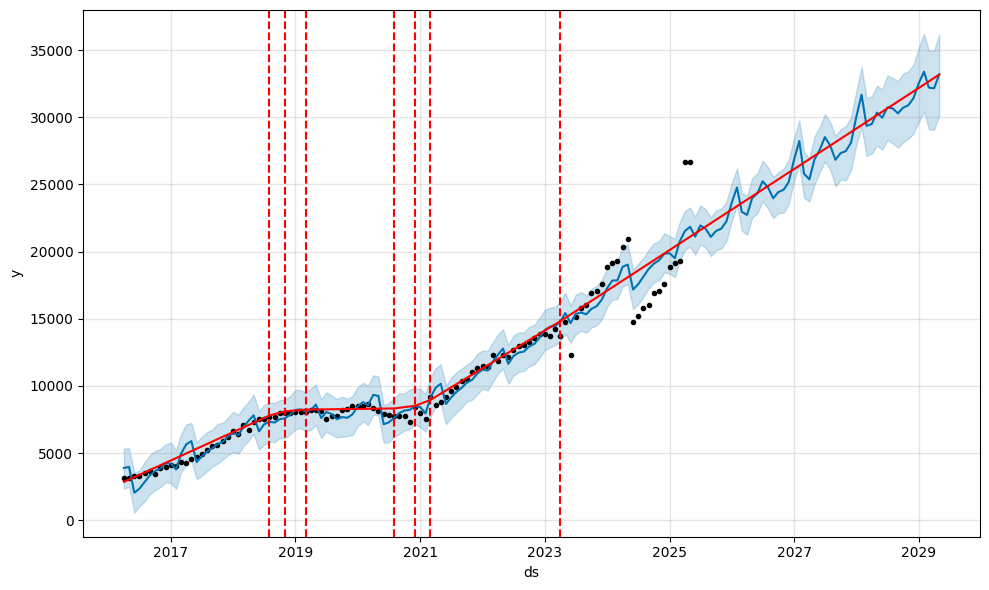

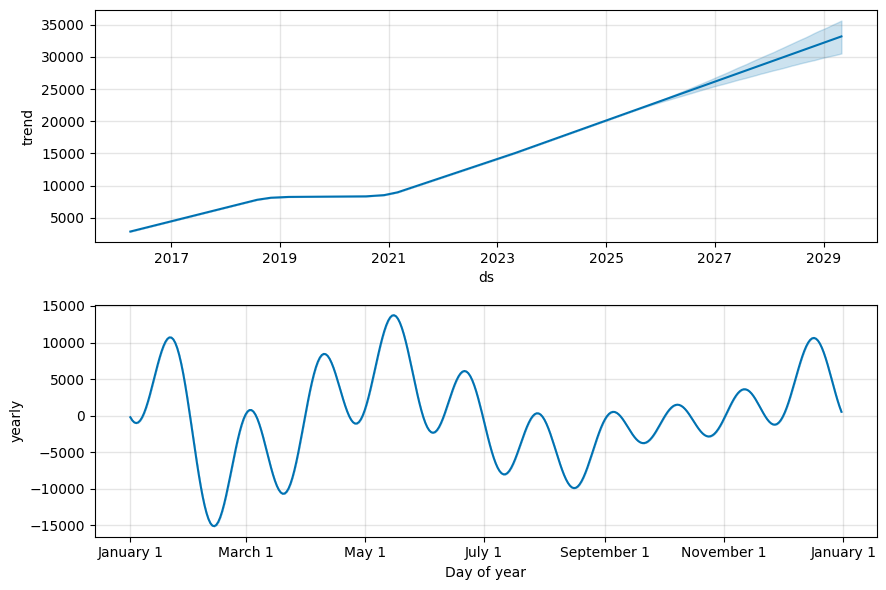

In [78]:
# Check trend changepoints
from prophet.plot import add_changepoints_to_plot
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()

# Component analysis
model.plot_components(forecast)
plt.show()

In [79]:
# Cross-validation (evaluate forecast quality)
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='1825 days', period='180 days', horizon='365 days')
from prophet.diagnostics import performance_metrics
print(performance_metrics(df_cv).head())

  0%|          | 0/7 [00:00<?, ?it/s]17:24:22 - cmdstanpy - INFO - Chain [1] start processing
17:24:22 - cmdstanpy - INFO - Chain [1] done processing
 14%|█▍        | 1/7 [00:00<00:02,  2.04it/s]17:24:22 - cmdstanpy - INFO - Chain [1] start processing
17:24:23 - cmdstanpy - INFO - Chain [1] done processing
 29%|██▊       | 2/7 [00:01<00:03,  1.43it/s]17:24:23 - cmdstanpy - INFO - Chain [1] start processing
17:24:24 - cmdstanpy - INFO - Chain [1] done processing
 43%|████▎     | 3/7 [00:02<00:03,  1.29it/s]17:24:24 - cmdstanpy - INFO - Chain [1] start processing
17:24:25 - cmdstanpy - INFO - Chain [1] done processing
 57%|█████▋    | 4/7 [00:03<00:02,  1.20it/s]17:24:25 - cmdstanpy - INFO - Chain [1] start processing
17:24:26 - cmdstanpy - INFO - Chain [1] done processing
 71%|███████▏  | 5/7 [00:03<00:01,  1.24it/s]17:24:26 - cmdstanpy - INFO - Chain [1] start processing
17:24:27 - cmdstanpy - INFO - Chain [1] done processing
 86%|████████▌ | 6/7 [00:04<00:00,  1.20it/s]17:24:27 - cmds

  horizon           mse         rmse          mae      mape     mdape  \
0 45 days  4.458883e+06  2111.606843  1537.675432  0.119282  0.084965   
1 49 days  4.398019e+06  2097.145465  1486.887082  0.112626  0.069651   
2 50 days  4.394150e+06  2096.222904  1478.800829  0.111661  0.069651   
3 54 days  4.364987e+06  2089.255101  1454.243058  0.109006  0.059032   
4 55 days  4.377681e+06  2092.290802  1473.183110  0.110057  0.059032   

      smape  coverage  
0  0.113230       0.0  
1  0.106147       0.0  
2  0.105129       0.0  
3  0.102593       0.0  
4  0.103713       0.0  


17:24:28 - cmdstanpy - INFO - Chain [1] start processing
17:24:28 - cmdstanpy - INFO - Chain [1] done processing


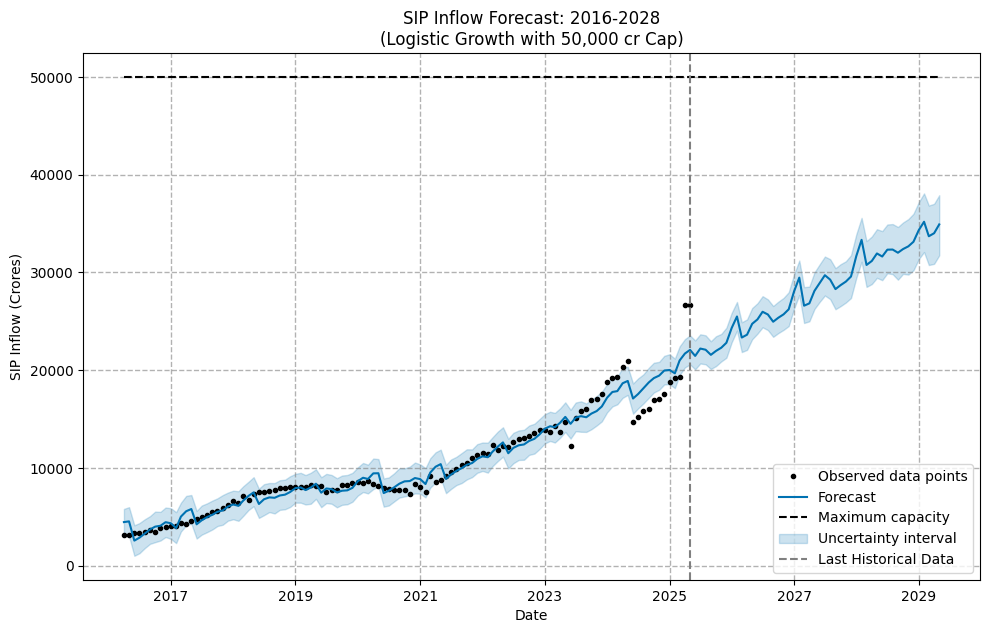

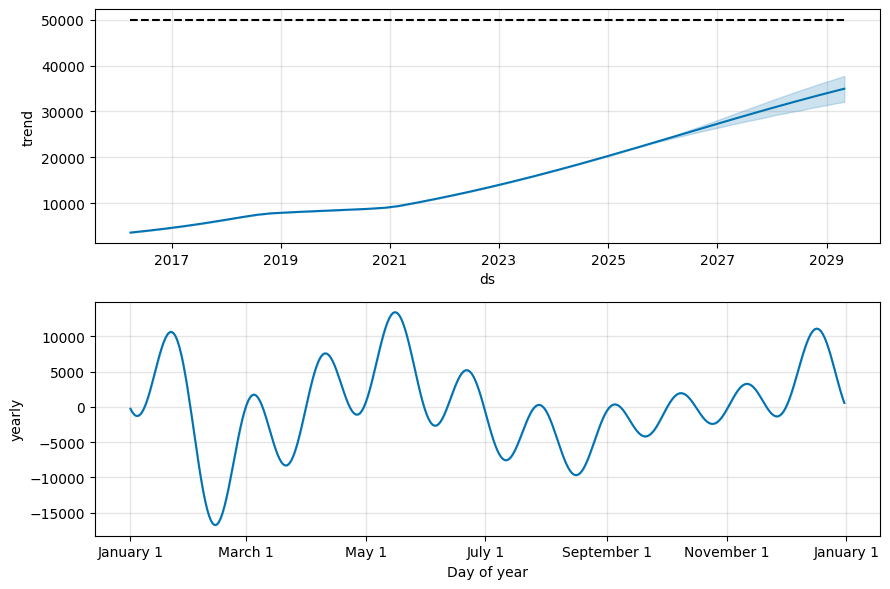

In [80]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare data with capacity for logistic growth
prophet_df = (
    df.reset_index()[['Date', 'SIP_Inflow_Crores']]
    .rename(columns={'Date': 'ds', 'SIP_Inflow_Crores': 'y'})
)
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])  # Ensure datetime format
prophet_df['cap'] = 50000  # Set capacity ceiling for logistic growth

# 2. Initialize and fit model
model = Prophet(
    growth='logistic',            # Logistic growth for market saturation
    changepoint_prior_scale=0.5,  # Medium trend flexibility
    yearly_seasonality=True,      # Capture annual patterns
    weekly_seasonality=False,     # Disabled for monthly data
    daily_seasonality=False,      # Disabled for monthly data
    seasonality_mode='additive'   # Seasonal components add to trend
)

model.fit(prophet_df)

# 3. Create future dataframe with capacity
future = model.make_future_dataframe(periods=48, freq='ME')  # 'ME' = Month End
future['cap'] = 50000  # Maintain same capacity for future

# 4. Generate forecast
forecast = model.predict(future)

# 5. Enhanced visualization
fig = model.plot(forecast, xlabel='Date', ylabel='SIP Inflow (Crores)')
plt.title('SIP Inflow Forecast: 2016-2028\n(Logistic Growth with 50,000 cr Cap)')
plt.axvline(
    x=prophet_df['ds'].max(),
    color='grey',
    linestyle='--',
    label='Last Historical Data'
)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Plot components (trend + seasonality)
fig2 = model.plot_components(forecast)
plt.tight_layout()  # Prevent label overlap
plt.show()

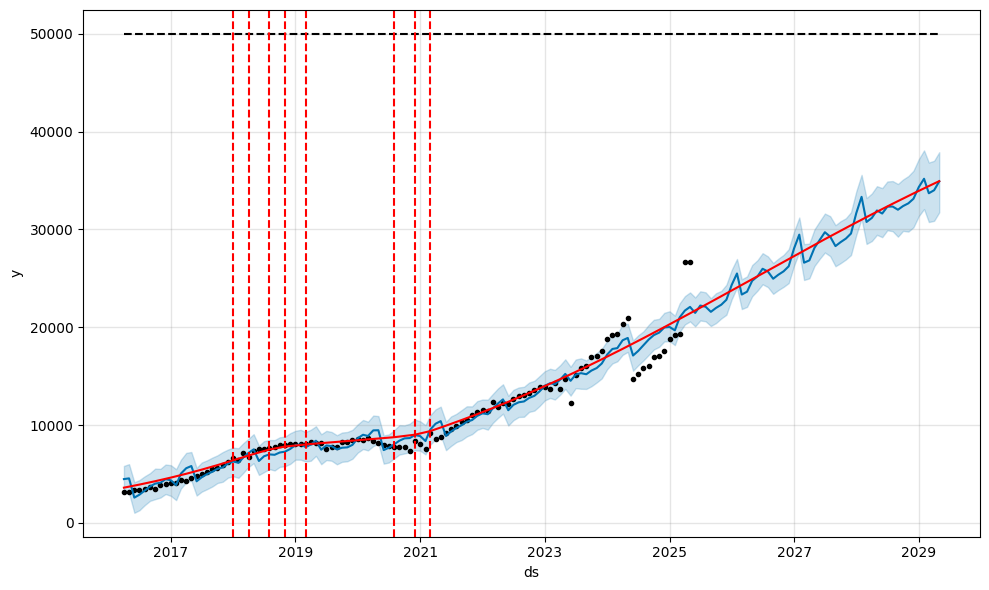

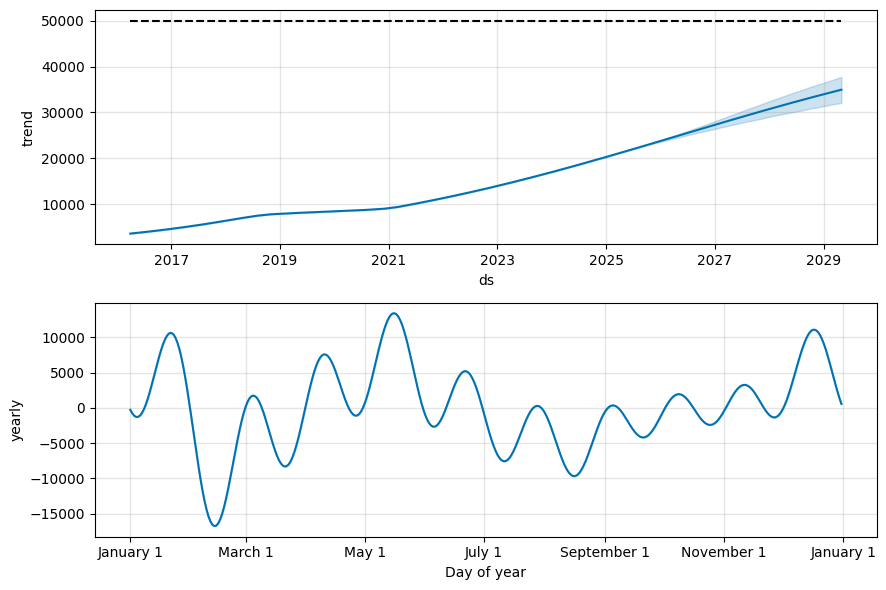

In [81]:
# Check trend changepoints
from prophet.plot import add_changepoints_to_plot
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()

# Component analysis
model.plot_components(forecast)
plt.show()

In [82]:
linear_model = Prophet(
    growth='linear',
    changepoint_prior_scale=0.5,
    yearly_seasonality=True
)
linear_model.fit(prophet_df)  # No 'cap' column needed

17:24:30 - cmdstanpy - INFO - Chain [1] start processing
17:24:30 - cmdstanpy - INFO - Chain [1] done processing


In [83]:
logistic_model = Prophet(
    growth='logistic',
    changepoint_prior_scale=0.5,
    yearly_seasonality=True
)
prophet_df['cap'] = 50000  # Market capacity assumption (e.g., 50,000 crores)
logistic_model.fit(prophet_df)

17:24:30 - cmdstanpy - INFO - Chain [1] start processing
17:24:30 - cmdstanpy - INFO - Chain [1] done processing


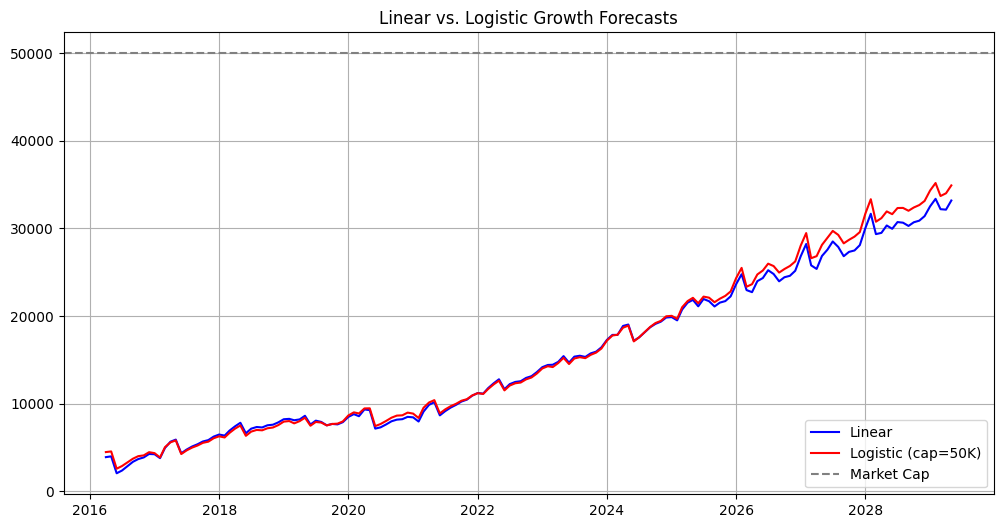

In [84]:
# Generate futures (both use same periods)
future = linear_model.make_future_dataframe(periods=48, freq='ME')
future_logistic = future.copy()
future_logistic['cap'] = 50000  # Required for logistic

# Predict
linear_forecast = linear_model.predict(future)
logistic_forecast = logistic_model.predict(future_logistic)

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(linear_forecast['ds'], linear_forecast['yhat'], label='Linear', color='blue')
plt.plot(logistic_forecast['ds'], logistic_forecast['yhat'], label='Logistic (cap=50K)', color='red')
plt.axhline(y=50000, linestyle='--', color='gray', label='Market Cap')
plt.title('Linear vs. Logistic Growth Forecasts')
plt.legend()
plt.grid(True)
plt.show()

In [85]:
from prophet.diagnostics import cross_validation, performance_metrics

# Linear model CV
df_cv_linear = cross_validation(linear_model, initial='1825 days', period='180 days', horizon='365 days')
metrics_linear = performance_metrics(df_cv_linear)

# Logistic model CV
df_cv_logistic = cross_validation(logistic_model, initial='1825 days', period='180 days', horizon='365 days')
metrics_logistic = performance_metrics(df_cv_logistic)

print("Linear MAE:", metrics_linear['mae'].mean())
print("Logistic MAE:", metrics_logistic['mae'].mean())

  0%|          | 0/7 [00:00<?, ?it/s]17:24:30 - cmdstanpy - INFO - Chain [1] start processing
17:24:31 - cmdstanpy - INFO - Chain [1] done processing
 14%|█▍        | 1/7 [00:00<00:02,  2.10it/s]17:24:31 - cmdstanpy - INFO - Chain [1] start processing
17:24:31 - cmdstanpy - INFO - Chain [1] done processing
 29%|██▊       | 2/7 [00:01<00:03,  1.44it/s]17:24:32 - cmdstanpy - INFO - Chain [1] start processing
17:24:32 - cmdstanpy - INFO - Chain [1] done processing
 43%|████▎     | 3/7 [00:02<00:03,  1.26it/s]17:24:32 - cmdstanpy - INFO - Chain [1] start processing
17:24:33 - cmdstanpy - INFO - Chain [1] done processing
 57%|█████▋    | 4/7 [00:03<00:02,  1.21it/s]17:24:33 - cmdstanpy - INFO - Chain [1] start processing
17:24:34 - cmdstanpy - INFO - Chain [1] done processing
 71%|███████▏  | 5/7 [00:03<00:01,  1.23it/s]17:24:34 - cmdstanpy - INFO - Chain [1] start processing
17:24:35 - cmdstanpy - INFO - Chain [1] done processing
 86%|████████▌ | 6/7 [00:04<00:00,  1.19it/s]17:24:35 - cmds

Linear MAE: 1857.9344872588745
Logistic MAE: 1995.858323872551


In [86]:
from prophet import Prophet

# Load data (adapt to your CSV structure)
df = pd.read_csv('sip_forecast_2028.csv')

# Option A: If CSV has Prophet output format
if 'ds' in df.columns:
    prophet_df = df[['ds', 'yhat']].rename(columns={'yhat': 'y'})
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Option B: If CSV has raw data
else:
    prophet_df = df[['Date', 'SIP_Inflow_Crores']].rename(columns={'Date': 'ds', 'SIP_Inflow_Crores': 'y'})
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Fit models
linear_model = Prophet(growth='linear').fit(prophet_df)
prophet_df['cap'] = 50000  # For logistic
logistic_model = Prophet(growth='logistic').fit(prophet_df)

# Compare December 2025
future = pd.DataFrame({'ds': ['2025-12-31'], 'cap': [50000]})
linear_pred = linear_model.predict(future)['yhat'].values[0]
logistic_pred = logistic_model.predict(future)['yhat'].values[0]

print(f"Linear: {linear_pred:.2f} crores | Logistic: {logistic_pred:.2f} crores")

17:24:51 - cmdstanpy - INFO - Chain [1] start processing
17:24:51 - cmdstanpy - INFO - Chain [1] done processing
17:24:51 - cmdstanpy - INFO - Chain [1] start processing
17:24:52 - cmdstanpy - INFO - Chain [1] done processing


Linear: 22942.29 crores | Logistic: 22942.31 crores


In [87]:
from sklearn.metrics import mean_absolute_error
linear_mae = mean_absolute_error(prophet_df['y'], linear_model.predict(prophet_df)['yhat'])
logistic_mae = mean_absolute_error(prophet_df['y'], logistic_model.predict(prophet_df)['yhat'])
print(f"Linear MAE: {linear_mae:.2f}, Logistic MAE: {logistic_mae:.2f}")

Linear MAE: 2.21, Logistic MAE: 7.25
